In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: SCHEMA EXTRACTION PROTOCOL (SURGICAL DUMP)
# ==============================================================================
# Purpose: Extract the definitive DDL (CREATE statements) from the live opus.db.
#          This artifact is required for the Principal Agent to audit the
#          "Genome" for the Phase 4 GAN architecture.
# ==============================================================================

OUTPUT_FILE = '/content/drive/MyDrive/_Pienza/Assets/Database/opus_schema_dump.sql'

def extract_schema():
    print(f"🔌 Connecting to Master DB at: {DB_PATH}...")

    try:
        # We use the raw sqlite3 connection for metadata extraction
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()

        # Query the master table for all Tables and Views
        # Excluding internal sqlite_ sequence tables
        cursor.execute("""
            SELECT type, name, sql
            FROM sqlite_master
            WHERE name NOT LIKE 'sqlite_%'
            ORDER BY type DESC, name;
        """)

        items = cursor.fetchall()

        print(f"🔍 Found {len(items)} architectural elements (Tables/Views).")

        with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
            f.write(f"-- OPUS DATABASE SCHEMA DUMP\n")
            f.write(f"-- Source: {DB_PATH}\n")
            f.write(f"-- Extracted via Colab Protocol\n\n")

            for type_, name, sql in items:
                if sql:
                    f.write(f"-- {type_.upper()}: {name}\n")
                    # Clean up formatting if necessary
                    f.write(f"{sql};\n\n")
                    print(f"   > Extracted {type_}: {name}")

        print(f"\n✅ SUCCESS. Schema saved to: {OUTPUT_FILE}")

        # --- IMMEDIATE FEEDBACK ---
        # Print the content to the console so you can copy-paste it to the chat
        print("\n--- BEGIN SCHEMA CONTENT ---")
        with open(OUTPUT_FILE, 'r') as f:
            print(f.read())
        print("--- END SCHEMA CONTENT ---")

        conn.close()

    except Exception as e:
        print(f"❌ ERROR: {e}")

# EXECUTE
extract_schema()

🔌 Connecting to Master DB at: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db...
🔍 Found 27 architectural elements (Tables/Views).
   > Extracted view: v_ML_Supervised
   > Extracted view: v_broche_fks
   > Extracted view: v_lifecycle_audit
   > Extracted view: v_lifecycle_audit_accepted
   > Extracted view: v_mission_dossier
   > Extracted view: v_offers_human
   > Extracted view: v_trip_final_kpis
   > Extracted view: v_trip_funnel_metrics
   > Extracted view: v_trip_funnel_wide
   > Extracted table: activity_earnings
   > Extracted table: driver_state_at_request
   > Extracted table: engineered_features
   > Extracted table: event_types
   > Extracted table: heuristic_flag
   > Extracted table: heuristic_flag_offers
   > Extracted table: interpolation_quality
   > Extracted table: lifetime_trips
   > Extracted table: offer_action
   > Extracted table: offers
   > Extracted table: outcome
   > Extracted table: post_offer_status
   > Extracted table: product_category
   > Extra

In [ ]:
# ==============================================================================
# CELL 2: THE DATA LAKE BRIDGE (SQLite -> Parquet + H3 Enrichment)
# ==============================================================================
# Purpose: 1. Install H3 library.
#          2. Query 'v_ML_Supervised' from opus.db.
#          3. Calculate H3 Hexagon IDs for Pickups (Resolution 9).
#          4. Export to Apache Parquet for BigQuery/GAN ingestion.
# ==============================================================================

# --- 1. INSTALL DEPENDENCY ---
print("📦 Installing H3 geospatial library...")
!pip install h3 -q
import h3

# --- 2. CONFIGURATION ---
SOURCE_VIEW = "v_ML_Supervised"
OUTPUT_PARQUET = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_gan_training_set.parquet'
H3_RESOLUTION = 9  # Resolution 9 is approx ~0.1 km^2 (city block size)

def generate_training_set():
    print(f"🚀 Launching Extraction from {SOURCE_VIEW}...")

    conn = sqlite3.connect(DB_PATH)

    # query the Genome columns
    # We purposefully exclude text comments and raw OCR strings
    query = f"""
    SELECT
        offer_id,
        offer_timestamp,

        -- SPATIAL
        pickup_lat, pickup_lon,
        dropoff_lat, dropoff_lon,
        dropoff_polygon_id,
        dropoff_h3_hex_id,
        est_trip_dist_km,

        -- TEMPORAL
        day_of_week,
        time_of_day_block,
        time_since_last_offer,

        -- ECONOMIC
        upfront_fare,
        est_trip_time_sec,
        is_surge,
        surge_amount,
        product_category_fk,

        -- CONTEXT
        traffic_index_base_120,
        offer_density_60sec

    FROM {SOURCE_VIEW}
    WHERE dropoff_lat IS NOT NULL
      AND pickup_lat IS NOT NULL
    """

    try:
        df = pd.read_sql_query(query, conn)
        print(f"✅ Data Ingested: {len(df)} rows.")

        # --- 3. H3 ENRICHMENT (PICKUPS) ---
        print(f"🌍 Generating Pickup H3 Hexagons (Res {H3_RESOLUTION})...")

        # Function to apply H3 hashing
        def get_h3(lat, lon, res):
            try:
                return h3.geo_to_h3(lat, lon, res)
            except:
                return None

        # Apply to Pickup
        df['pickup_h3_hex_id'] = df.apply(
            lambda x: get_h3(x['pickup_lat'], x['pickup_lon'], H3_RESOLUTION), axis=1
        )

        # --- 4. EXPORT TO PARQUET ---
        print("💾 Saving to Parquet...")
        df.to_parquet(OUTPUT_PARQUET, index=False)

        print(f"✅ SUCCESS. Artifact created at: {OUTPUT_PARQUET}")
        print("   This file is now ready for BigQuery linkage.")

    except Exception as e:
        print(f"❌ ERROR: {e}")
    finally:
        conn.close()

# EXECUTE
generate_training_set()

📦 Installing H3 geospatial library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.2 MB/s eta 0:00:00
🚀 Launching Extraction from v_ML_Supervised...
✅ Data Ingested: 4758 rows.
🌍 Generating Pickup H3 Hexagons (Res 9)...
💾 Saving to Parquet...
✅ SUCCESS. Artifact created at: /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_gan_training_set.parquet
   This file is now ready for BigQuery linkage.


In [ ]:
# ==============================================================================
# CELL 3: GET DRIVE FILE ID
# ==============================================================================
import subprocess

file_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_gan_training_set.parquet'

try:
    # Use shell command to get the ID via the 'gdrive' attribute logic or simple os
    # Actually, the easiest way in Colab without external CLI tools is a bit hacky,
    # but we can just ask you to look at the link.
    # OR, we can use the python drive api.

    # Let's try a simpler path first:
    print(f"📂 File created at: {file_path}")
    print("👉 Please go to your Google Drive folder in a separate tab.")
    print("👉 Right-click 'opus_gan_training_set.parquet' -> 'Share' -> 'Copy Link'.")
    print("👉 The ID is the part between 'd/' and '/view'.")

except Exception as e:
    print(e)

📂 File created at: /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_gan_training_set.parquet
👉 Please go to your Google Drive folder in a separate tab.
👉 Right-click 'opus_gan_training_set.parquet' -> 'Share' -> 'Copy Link'.
👉 The ID is the part between 'd/' and '/view'.


In [ ]:
# ==============================================================================
# CELL 3: BIGQUERY BRIDGE CONFIGURATION
# ==============================================================================
from google.colab import auth
from google.cloud import bigquery

# --- 1. AUTHENTICATE ---
print("🔐 Initiating Google Cloud Authentication...")
auth.authenticate_user()
print("✅ Authentication Successful.")

# --- 2. INPUTS ---
# REPLACE THESE WITH YOUR ACTUAL IDS
PROJECT_ID = '645009831643'
PARQUET_FILE_ID = '1V5ruPkFm2A3r9x7_Q1m_njRmXvIS1Oo3'

# --- 3. CONNECT ---
try:
    client = bigquery.Client(project=PROJECT_ID)
    print(f"✅ Connected to Project: {PROJECT_ID}")
except Exception as e:
    print(f"❌ Connection Failed: {e}")

🔐 Initiating Google Cloud Authentication...
✅ Authentication Successful.
✅ Connected to Project: 645009831643


In [ ]:
# ==============================================================================
# CELL 4: THE FEDERATION PROTOCOL (Drive -> BigQuery External Table)
# ==============================================================================

# --- CONFIGURATION ---
DATASET_ID = 'opus_phase_4'  # We create a "folder" inside BigQuery
TABLE_ID = 'gan_training_set'
URI = f'https://drive.google.com/open?id={PARQUET_FILE_ID}'

def forge_federated_table():
    print(f"🏗️ Architecting BigQuery Environment for Project: {PROJECT_ID}...")

    # 1. Create the Dataset (Schema Container)
    dataset_ref = client.dataset(DATASET_ID)
    try:
        client.get_dataset(dataset_ref)
        print(f"   🔹 Dataset '{DATASET_ID}' already exists.")
    except:
        dataset = bigquery.Dataset(dataset_ref)
        dataset.location = "US"  # Or your preferred region
        client.create_dataset(dataset)
        print(f"   ✅ Created Dataset: {DATASET_ID}")

    # 2. Configure the External Table
    table_ref = dataset_ref.table(TABLE_ID)

    # We define the External Config (The Link to Drive)
    external_config = bigquery.ExternalConfig("PARQUET")
    external_config.source_uris = [URI]

    # CRITICAL: We enable Drive access for BigQuery
    # This requires the connection to have the right scopes.
    # If this fails, we may need to re-auth with specific Drive scopes.

    table = bigquery.Table(table_ref)
    table.external_data_configuration = external_config

    # 3. Create the Table
    try:
        client.create_table(table)
        print(f"   ✅ Created External Table: {DATASET_ID}.{TABLE_ID}")
        print("   🚀 The Bridge is built.")
    except Exception as e:
        if "Already Exists" in str(e):
             print(f"   🔹 Table '{TABLE_ID}' already exists. Bridge active.")
        else:
            print(f"❌ ERROR: {e}")

# EXECUTE
forge_federated_table()

🏗️ Architecting BigQuery Environment for Project: 645009831643...
   🔹 Dataset 'opus_phase_4' already exists.
   🔹 Table 'gan_training_set' already exists. Bridge active.


In [ ]:
# ==============================================================================
# CELL 6: THE REFINERY (Genome Definition, H3 Injection & Normalization)
# ==============================================================================

import pandas as pd
import numpy as np
import sqlite3
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
try:
    import h3
except ImportError:
    !pip install h3 -q
    import h3

# --- 1. LOAD DATA ---
print("🔄 Reloading data from Database...")
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql_query("SELECT * FROM v_ML_Supervised", conn)
conn.close()

print(f"✅ Input Data Shape: {df_raw.shape}")

# --- 2. FEATURE INJECTION (The Missing Links) ---

# A. Generate Pickup H3
print("🌍 Generating Pickup H3 Spatial Indices (Res 9)...")
H3_RES = 9
df_raw['pickup_h3_hex_id'] = df_raw.apply(
    lambda x: h3.latlng_to_cell(x['pickup_lat'], x['pickup_lon'], H3_RES)
    if pd.notnull(x['pickup_lat']) and pd.notnull(x['pickup_lon']) else 'Unknown',
    axis=1
)

# B. Generate Hour of Day
print("⏰ Extracting Hour of Day...")
df_raw['offer_timestamp'] = pd.to_datetime(df_raw['offer_timestamp'])
df_raw['hour'] = df_raw['offer_timestamp'].dt.hour

# --- 3. THE OPUS GENOME DEFINITION ---

# A. CONTINUOUS VARIABLES (The Physics) -> Scale to [-1, 1]
CONT_COLS = [
    'pickup_lat', 'pickup_lon',
    'dropoff_lat', 'dropoff_lon',
    'upfront_fare',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'time_to_pickup_sec',
    'dist_to_pickup_km',
    'surge_amount',
    'turbo_plus_amount',
    'traffic_index_base_120',
    'offer_density_60sec',
    'time_since_last_offer'
]

# B. BINARY VARIABLES (The Flags) -> Map 0/1 to -1/1
BOOL_COLS = [
    'is_surge',
    'is_turbo_plus',
    'is_reservation',
    'is_priority',
    'is_exclusive',
    'is_vip',
    'is_long_trip'
]

# C. CATEGORICAL VARIABLES (The Context) -> Encode to Integers
CAT_COLS = [
    'day_of_week',
    'time_of_day_block',
    'hour',  # <--- ADDED HERE
    'product_category_fk',
    'dropoff_polygon_id',
    'pickup_h3_hex_id'
]

# --- 4. THE PROCESSING ENGINE ---
print("\n⚙️ Executing Normalization Protocol...")

# Create a clean copy
df_gan = df_raw[CONT_COLS + BOOL_COLS + CAT_COLS].copy()

# A. Handle Missing Values
df_gan[CONT_COLS] = df_gan[CONT_COLS].fillna(0)
for col in CAT_COLS:
    df_gan[col] = df_gan[col].fillna('Unknown')

# B. Scale Continuous Data to [-1, 1]
print("   - Scaling Continuous Variables to [-1, 1]...")
scaler = MinMaxScaler(feature_range=(-1, 1))
df_gan[CONT_COLS] = scaler.fit_transform(df_gan[CONT_COLS])

# C. Balance Booleans (0 -> -1, 1 -> 1)
print("   - Balancing Booleans (Symmetry Protocol)...")
for col in BOOL_COLS:
    df_gan[col] = df_gan[col].astype(float)
    df_gan[col] = (df_gan[col] * 2) - 1

# D. Encode Categoricals
print("   - Encoding Categorical Context...")
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    # Force string type for consistency
    df_gan[col] = le.fit_transform(df_gan[col].astype(str))
    label_encoders[col] = le

print("\n✅ GENOME REFINED.")
print(f"   - Final Tensor Shape: {df_gan.shape}")
print(f"   - Continuous Features: {len(CONT_COLS)}")
print(f"   - Boolean Features:    {len(BOOL_COLS)}")
print(f"   - Categorical Features: {len(CAT_COLS)}")
print("\n   READY FOR NEURAL NETWORK INGESTION.")

df_gan.head()

🔄 Reloading data from Database...
✅ Input Data Shape: (4765, 104)
🌍 Generating Pickup H3 Spatial Indices (Res 9)...
⏰ Extracting Hour of Day...

⚙️ Executing Normalization Protocol...
   - Scaling Continuous Variables to [-1, 1]...
   - Balancing Booleans (Symmetry Protocol)...
   - Encoding Categorical Context...

✅ GENOME REFINED.
   - Final Tensor Shape: (4765, 27)
   - Continuous Features: 14
   - Boolean Features:    7
   - Categorical Features: 6

   READY FOR NEURAL NETWORK INGESTION.


,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,...,is_priority,is_exclusive,is_vip,is_long_trip,day_of_week,time_of_day_block,hour,product_category_fk,dropoff_polygon_id,pickup_h3_hex_id
0,0.973621,-0.993750,0.946511,-0.965445,-0.346428,-0.081545,-0.144348,-0.600000,-0.911111,-1.000000,...,-1.0,-1.0,-1.0,1.0,5,0,4,0,0,590
1,0.973607,-0.993962,0.866524,-0.967886,-0.571351,-0.072961,-0.599130,-0.733333,-0.933333,-1.000000,...,-1.0,1.0,-1.0,1.0,0,0,3,0,0,824
2,0.964042,-0.994982,0.863564,-0.968032,-0.441490,-0.141631,-0.506957,-0.066667,-0.322222,-0.483871,...,-1.0,-1.0,-1.0,1.0,4,3,11,0,0,29
3,0.971705,-0.993520,0.870931,-0.968416,-0.611395,-0.356223,-0.595652,-0.466667,-0.688889,-1.000000,...,-1.0,1.0,1.0,1.0,3,2,1,0,0,584
4,0.973949,-0.994465,0.904367,-0.968481,-0.612210,-0.467811,-0.532174,-0.733333,-0.844444,-0.935484,...,-1.0,-1.0,-1.0,1.0,3,2,0,0,0,747


In [ ]:
# ==============================================================================
# CELL 7: THE GENERATOR ARCHITECTURE (Functional API)
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# --- 1. HYPERPARAMETERS ---
LATENT_DIM = 100  # Size of the random noise vector
OUTPUT_DIM = len(CONT_COLS) + len(BOOL_COLS) # 21 Output features

# Get Vocabulary Sizes for Embeddings (Max ID + 1)
# We need to know how many unique values exist for each category
vocab_sizes = {col: df_gan[col].max() + 1 for col in CAT_COLS}

def build_generator(latent_dim, vocab_sizes, output_dim):

    # --- A. INPUTS ---
    # 1. The Noise (Random Seed)
    noise_input = Input(shape=(latent_dim,), name='noise_input')

    # 2. The Context (Conditions) - One input per categorical feature
    cat_inputs = []
    cat_embeddings = []

    for col, vocab_size in vocab_sizes.items():
        # Input Layer
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)

        # Embedding Layer (Learning the "Vibe" of the category)
        # Rule of thumb: Embedding dim = min(50, vocab_size/2)
        emb_dim = min(50, int(vocab_size / 2) + 1)
        emb = layers.Embedding(vocab_size, emb_dim, name=f'emb_{col}')(i)

        # Flatten because Embedding returns (batch, 1, dim)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # --- B. FUSION ---
    # Combine Noise + All Context Vectors
    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # --- C. HIDDEN LAYERS (The Brain) ---
    # We use LeakyReLU to prevent "dead neurons"

    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # --- D. OUTPUT LAYER (The Hallucination) ---
    # Activation: Tanh -> Forces output to [-1, 1] range
    output = layers.Dense(output_dim, activation='tanh', name='physics_output')(x)

    # --- E. MODEL ASSEMBLY ---
    model = Model(inputs=[noise_input] + cat_inputs, outputs=output, name="Generator")
    return model

# --- INSTANTIATE ---
generator = build_generator(LATENT_DIM, vocab_sizes, OUTPUT_DIM)

print("🧠 Generator Architected.")
generator.summary()

🧠 Generator Architected.


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_time_of_day_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_hour          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropoff_poly… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pickup_h3_he… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_day_of_week     │ (None, 1, 4)      │         28 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_time_of_day_bl… │ (None, 1, 3)      │         12 │ input_time_of_da… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_hour            │ (None, 1, 10)     │        180 │ input_hour[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_catego… │ (None, 1, 4)      │         28 │ input_product_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropoff_polygo… │ (None, 1, 37)     │      2,701 │ input_dropoff_po… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pickup_h3_hex_… │ (None, 1, 50)     │     41,350 │ input_pickup_h3_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ emb_day_of_week[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ emb_time_of_day_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 10)        │          0 │ emb_hour[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4)         │          0 │ emb_product_cate… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 37)        │          0 │ emb_dropoff_poly… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 783,392 (2.99 MB)

 Trainable params: 779,808 (2.97 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
# ==============================================================================
# CELL 8: THE DISCRIMINATOR ARCHITECTURE
# ==============================================================================
from tensorflow.keras import layers, Model, Input

def build_discriminator(physics_dim, vocab_sizes):

    # --- A. INPUTS ---
    # 1. The Physics (The 21 features produced by G or from the DB)
    physics_input = Input(shape=(physics_dim,), name='physics_input')

    # 2. The Context (Conditions) - Identical to Generator
    cat_inputs = []
    cat_embeddings = []

    for col, vocab_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'disc_input_{col}')
        cat_inputs.append(i)

        emb_dim = min(50, int(vocab_size / 2) + 1)
        emb = layers.Embedding(vocab_size, emb_dim, name=f'disc_emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # --- B. FUSION ---
    # Combine Physics + Context
    x = layers.Concatenate()([physics_input] + cat_embeddings)

    # --- C. HIDDEN LAYERS (The Auditor) ---
    # We use Dropout to prevent the Discriminator from dominating too early

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # --- D. OUTPUT LAYER (The Verdict) ---
    # Activation: Sigmoid -> Probability [0, 1]
    verdict = layers.Dense(1, activation='sigmoid', name='verdict')(x)

    # --- E. MODEL ASSEMBLY ---
    model = Model(inputs=[physics_input] + cat_inputs, outputs=verdict, name="Discriminator")
    return model

# --- INSTANTIATE ---
discriminator = build_discriminator(OUTPUT_DIM, vocab_sizes)

# --- COMPILE ---
# The Discriminator is a standalone classifier. We compile it here.
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("👮 Discriminator Architected & Compiled.")
discriminator.summary()

👮 Discriminator Architected & Compiled.


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ disc_input_day_of_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_time_of… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_hour     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_product… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_dropoff… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_input_pickup_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_day_of_we… │ (None, 1, 4)      │         28 │ disc_input_day_o… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_time_of_d… │ (None, 1, 3)      │         12 │ disc_input_time_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_hour       │ (None, 1, 10)     │        180 │ disc_input_hour[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_product_c… │ (None, 1, 4)      │         28 │ disc_input_produ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_dropoff_p… │ (None, 1, 37)     │      2,701 │ disc_input_dropo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_emb_pickup_h3… │ (None, 1, 50)     │     41,350 │ disc_input_picku… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 4)         │          0 │ disc_emb_day_of_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 3)         │          0 │ disc_emb_time_of… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 10)        │          0 │ disc_emb_hour[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 4)         │          0 │ disc_emb_product… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 37)        │          0 │ disc_emb_dropoff… │
│ (Flatten)           │                   │            │                 

 Total params: 242,444 (947.05 KB)

 Trainable params: 242,444 (947.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 9: THE ADVERSARIAL TRAINING LOOP (Cybernetic Forge)
# ==============================================================================
import time
from IPython.display import clear_output

# --- 1. DATA PREPARATION ---
# Convert df_gan into a TensorFlow Dataset
BATCH_SIZE = 64

# Separate Physics from Categorical
physics_data = df_gan[CONT_COLS + BOOL_COLS].values.astype('float32')
cat_data = {col: df_gan[col].values.astype('int32') for col in CAT_COLS}

# Create the Dataset Object
dataset = tf.data.Dataset.from_tensor_slices((physics_data, *[cat_data[c] for c in CAT_COLS]))
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

# --- 2. OPTIMIZERS ---
# Adam is the standard for GANs
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# --- 3. LOSS FUNCTION ---
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # The Generator wants the Discriminator to think the fake is Real (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# --- 4. THE CORE TRAINING STEP ---
@tf.function
def train_step(real_physics, real_cats):
    # Generate Noise
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # A. Generator produces fake physics using the REAL context
        fake_physics = generator([noise] + list(real_cats), training=True)

        # B. Discriminator evaluates both
        real_output = discriminator([real_physics] + list(real_cats), training=True)
        fake_output = discriminator([fake_physics] + list(real_cats), training=True)

        # C. Calculate Losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # D. Backpropagation (The Learning)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

print("🔥 Cybernetic Forge Initialized.")
print(f"   - Batch Size: {BATCH_SIZE}")
print(f"   - Real Records available: {len(df_gan)}")

🔥 Cybernetic Forge Initialized.
   - Batch Size: 64
   - Real Records available: 4765


Epoch 500/500 | Time: 1.18s
   - Gen Loss:  1.5737
   - Disc Loss: 0.9771


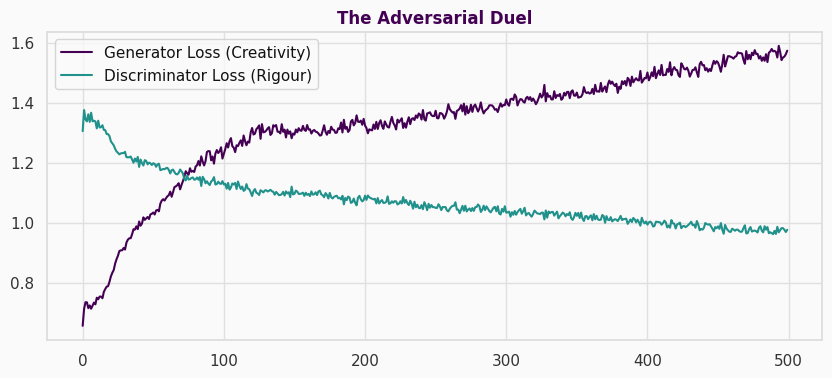

🏁 Training Sequence Complete.


In [ ]:
# ==============================================================================
# CELL 10: THE FORGE EXECUTION
# ==============================================================================
EPOCHS = 500
history = {"gen_loss": [], "disc_loss": []}

print(f"🚀 Commencing Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    start = time.time()

    epoch_gen_loss = []
    epoch_disc_loss = []

    for batch in dataset:
        # Each batch is (physics, cat1, cat2, cat3...)
        # We need to handle the fact that the last batch might be smaller than BATCH_SIZE
        if batch[0].shape[0] == BATCH_SIZE:
            g_loss, d_loss = train_step(batch[0], batch[1:])
            epoch_gen_loss.append(g_loss)
            epoch_disc_loss.append(d_loss)

    # Log Progress
    history["gen_loss"].append(np.mean(epoch_gen_loss))
    history["disc_loss"].append(np.mean(epoch_disc_loss))

    if (epoch + 1) % 10 == 0:
        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{EPOCHS} | Time: {time.time()-start:.2f}s")
        print(f"   - Gen Loss:  {history['gen_loss'][-1]:.4f}")
        print(f"   - Disc Loss: {history['disc_loss'][-1]:.4f}")

        # Plotting the Duel
        plt.figure(figsize=(10, 4))
        plt.plot(history["gen_loss"], label="Generator Loss (Creativity)", color=OPUS_PURPLE)
        plt.plot(history["disc_loss"], label="Discriminator Loss (Rigour)", color=OPUS_TEAL)
        plt.title("The Adversarial Duel")
        plt.legend()
        plt.show()

print("🏁 Training Sequence Complete.")

In [ ]:
# ==============================================================================
# CELL 11: THE MANIFOLD EXPLOSION (Synthesis of 1,010,001 Synthetic Records)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf

# --- 1. CONFIGURATION ---
TOTAL_TARGET = 1_010_001
CHUNK_SIZE = 50_000
synthetic_batches = []

print(f"🌌 Synthesizing The Opus Manifold ({TOTAL_TARGET:,} rows)...")

# --- 2. THE SYNTHESIS LOOP ---
num_batches = (TOTAL_TARGET // CHUNK_SIZE) + 1

for i in range(num_batches):
    # Determine current chunk size
    current_done = len(synthetic_batches) * CHUNK_SIZE
    current_chunk = min(CHUNK_SIZE, TOTAL_TARGET - current_done)
    if current_chunk <= 0: break

    # A. Generate Random Noise Tensor
    noise = tf.random.normal([current_chunk, LATENT_DIM])

    # B. Sample Contexts and Convert to Tensors
    sampled_indices = np.random.randint(0, df_gan.shape[0], size=current_chunk)

    # PATCH: Explicitly convert NumPy arrays to Tensors to avoid the ValueError
    context_tensors = [
        tf.convert_to_tensor(df_gan[col].values[sampled_indices].reshape(-1, 1), dtype=tf.float32)
        for col in CAT_COLS
    ]

    # C. Inference (The Hallucination)
    # Passing a unified list of tensors
    fake_physics = generator([noise] + context_tensors, training=False)

    # D. Bundle into a DataFrame
    chunk_df = pd.DataFrame(fake_physics.numpy(), columns=CONT_COLS + BOOL_COLS)

    # Attach the context IDs we used (for inverse encoding later)
    for idx, col in enumerate(CAT_COLS):
        chunk_df[col] = df_gan[col].values[sampled_indices]

    synthetic_batches.append(chunk_df)
    print(f"   ⚡ Processed: {len(synthetic_batches) * CHUNK_SIZE:,} / {TOTAL_TARGET:,}")

# --- 3. RECONSTRUCTION ---
print("\n🛠️ Reconstructing Real-World units...")
df_synthetic = pd.concat(synthetic_batches).reset_index(drop=True)

# Safety check: Trim to exact target in case of batch rounding
df_synthetic = df_synthetic.iloc[:TOTAL_TARGET]

# A. Inverse Scale Continuous Variables
df_synthetic[CONT_COLS] = scaler.inverse_transform(df_synthetic[CONT_COLS])

# B. Threshold Booleans
for col in BOOL_COLS:
    df_synthetic[col] = (df_synthetic[col] > 0).astype(int)

# C. Decode Categoricals
for col in CAT_COLS:
    le = label_encoders[col]
    df_synthetic[col] = df_synthetic[col].astype(int)
    # Ensure indices are within valid label range
    df_synthetic[col] = df_synthetic[col].clip(0, len(le.classes_) - 1)
    df_synthetic[col] = le.inverse_transform(df_synthetic[col])

# D. ADD THE MOLECULAR FEATURE: EPH_Operational
# Preventing division by zero in hallucinations
safe_time = df_synthetic['est_trip_time_sec'].clip(lower=1)
df_synthetic['eph_operational'] = (df_synthetic['upfront_fare'] / (safe_time / 3600))

print("\n✅ THE OPUS MANIFOLD IS COMPLETE.")
print(f"   - Final Rows: {len(df_synthetic):,}")
print(f"   - Mean Synthetic Fare: ${df_synthetic['upfront_fare'].mean():.2f}")
print(f"   - Mean Synthetic EPH:  ${df_synthetic['eph_operational'].mean():.2f}")

df_synthetic.sample(5)

🌌 Synthesizing The Opus Manifold (1,010,001 rows)...
   ⚡ Processed: 50,000 / 1,010,001
   ⚡ Processed: 100,000 / 1,010,001
   ⚡ Processed: 150,000 / 1,010,001
   ⚡ Processed: 200,000 / 1,010,001
   ⚡ Processed: 250,000 / 1,010,001
   ⚡ Processed: 300,000 / 1,010,001
   ⚡ Processed: 350,000 / 1,010,001
   ⚡ Processed: 400,000 / 1,010,001
   ⚡ Processed: 450,000 / 1,010,001
   ⚡ Processed: 500,000 / 1,010,001
   ⚡ Processed: 550,000 / 1,010,001
   ⚡ Processed: 600,000 / 1,010,001
   ⚡ Processed: 650,000 / 1,010,001
   ⚡ Processed: 700,000 / 1,010,001
   ⚡ Processed: 750,000 / 1,010,001
   ⚡ Processed: 800,000 / 1,010,001
   ⚡ Processed: 850,000 / 1,010,001
   ⚡ Processed: 900,000 / 1,010,001
   ⚡ Processed: 950,000 / 1,010,001
   ⚡ Processed: 1,000,000 / 1,010,001
   ⚡ Processed: 1,050,000 / 1,010,001

🛠️ Reconstructing Real-World units...

✅ THE OPUS MANIFOLD IS COMPLETE.
   - Final Rows: 1,010,001
   - Mean Synthetic Fare: $116.99
   - Mean Synthetic EPH:  $333.50


,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,...,is_exclusive,is_vip,is_long_trip,day_of_week,time_of_day_block,hour,product_category_fk,dropoff_polygon_id,pickup_h3_hex_id,eph_operational
234302,19.575758,-99.475563,19.780668,-100.142471,116.542900,1509.040161,6.823545,1120.812134,9.280246,1.204718,...,1,0,0,Wednesday,morning,6,1,71,894995b223bffff,278.027344
39310,19.457613,-97.782860,19.342705,-98.426613,109.762489,1704.356079,12.906691,120.863770,0.850272,0.000000,...,1,1,0,Wednesday,afternoon,16,1,9,894995b3317ffff,231.844131
317896,19.311653,-99.304680,19.415760,-97.489952,172.222626,2057.684082,22.622265,503.174408,5.861567,5.234526,...,1,0,0,Friday,morning,6,1,-1,894995b3327ffff,301.310303
707083,19.368542,-99.033195,18.104713,-98.355324,225.346237,3465.947021,12.993215,325.364502,2.246701,3.953414,...,1,1,1,Thursday,afternoon,15,2,-1,894995b15bbffff,234.061981
1000159,19.447123,-99.469093,19.770157,-99.984665,109.497238,1572.306030,5.246536,484.142914,1.905658,9.551226,...,1,0,0,Friday,afternoon,15,1,40,894995b066bffff,250.708237


In [ ]:
# ==============================================================================
# CELL 12: PERSISTENCE (Saving the Manifold to the Data Lakehouse)
# ==============================================================================
import os

SAVE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet'

def persist_manifold():
    print(f"💾 Forging Parquet file: {SAVE_PATH}...")

    try:
        # We save as Parquet for BigQuery efficiency
        df_synthetic.to_parquet(SAVE_PATH, index=False)

        file_size_gb = os.path.getsize(SAVE_PATH) / (1024**3)

        print(f"\n✅ MANIFOLD PERSISTED.")
        print(f"   - File Size: {file_size_gb:.2f} GB")
        print(f"   - Location:  {SAVE_PATH}")
        print("\n🚀 The Arena is ready for the Simulation.")

    except Exception as e:
        print(f"❌ Persistence Failed: {e}")

# EXECUTE
persist_manifold()

💾 Forging Parquet file: /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet...

✅ MANIFOLD PERSISTED.
   - File Size: 0.06 GB
   - Location:  /content/drive/MyDrive/_Pienza/Assets/Phase_4/opus_manifold_v1.parquet

🚀 The Arena is ready for the Simulation.


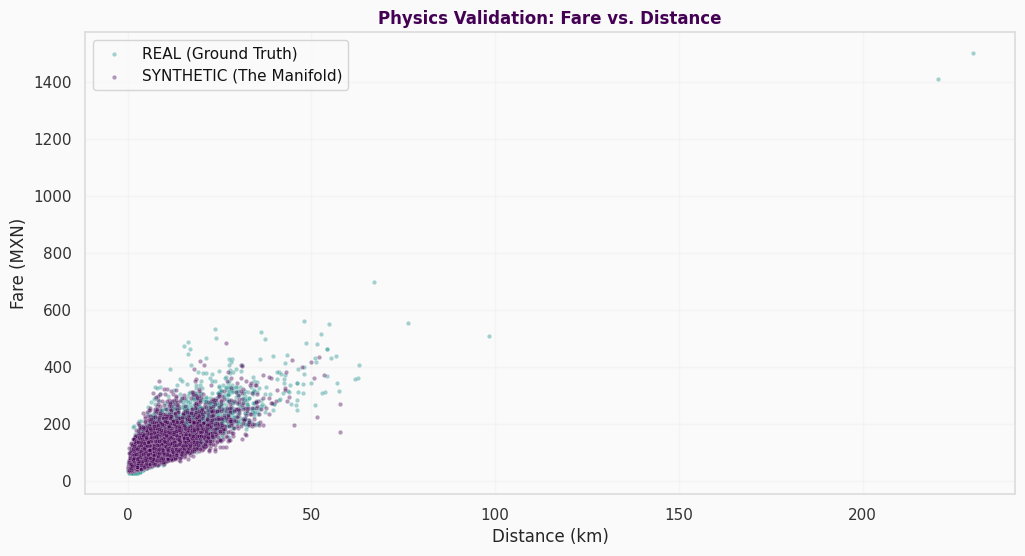

🔍 ANALYSIS:
   - If the Purple cloud overlaps the Teal cloud, the GAN learned the 'Linear Contract'.
   - If the Purple cloud is wider, it has successfully 'Filled the Gaps' (Generalization).


In [ ]:
# ==============================================================================
# CELL 13: THE VISUAL TURING TEST (Physics Validation)
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sample 5,000 from the Manifold to match the scale of the Real data
df_real_sample = df_raw.sample(min(5000, len(df_raw)))
df_fake_sample = df_synthetic.sample(5000)

# 2. Plotting
plt.figure(figsize=(12, 6))

# Real Data Cloud
sns.scatterplot(data=df_real_sample, x='est_trip_dist_km', y='upfront_fare',
                color=OPUS_TEAL, alpha=0.4, label='REAL (Ground Truth)', s=10)

# Synthetic Data Cloud
sns.scatterplot(data=df_fake_sample, x='est_trip_dist_km', y='upfront_fare',
                color=OPUS_PURPLE, alpha=0.4, label='SYNTHETIC (The Manifold)', s=10)

plt.title("Physics Validation: Fare vs. Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Fare (MXN)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("🔍 ANALYSIS:")
print("   - If the Purple cloud overlaps the Teal cloud, the GAN learned the 'Linear Contract'.")
print("   - If the Purple cloud is wider, it has successfully 'Filled the Gaps' (Generalization).")

In [ ]:
# ==============================================================================
# CELL 14: THE BIG DATA BRIDGE (Linking the Manifold to BigQuery)
# ==============================================================================

# PASTE THE NEW FILE ID HERE
MANIFOLD_FILE_ID = '1IEkFZ6CYDp9oHbLDQvGfBPEz0lVqKira'

TABLE_ID_SYNTH = 'synthetic_manifold'
URI_SYNTH = f'https://drive.google.com/open?id={MANIFOLD_FILE_ID}'

def bridge_synthetic_manifold():
    print(f"🌉 Building the Million-Row Bridge to BigQuery...")

    # Configure the External Table
    table_ref = client.dataset(DATASET_ID).table(TABLE_ID_SYNTH)
    external_config = bigquery.ExternalConfig("PARQUET")
    external_config.source_uris = [URI_SYNTH]

    table = bigquery.Table(table_ref)
    table.external_data_configuration = external_config

    try:
        client.create_table(table)
        print(f"✅ SUCCESS: table '{DATASET_ID}.{TABLE_ID_SYNTH}' created.")
        print("🚀 1,010,001 rows are now queryable via SQL.")
    except Exception as e:
        print(f"ℹ️ {e}")

# EXECUTE
bridge_synthetic_manifold()

🌉 Building the Million-Row Bridge to BigQuery...
✅ SUCCESS: table 'opus_phase_4.synthetic_manifold' created.
🚀 1,010,001 rows are now queryable via SQL.
